In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=[8,4]

In [61]:
df = pd.read_csv(r'D:\Project\diabeties_predictioin\data\diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [62]:
df.shape

(100000, 9)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [64]:
num = df.select_dtypes(include=np.number).columns
cat = df.select_dtypes(include='object').columns

C:\Users\zayan\AppData\Local\Temp\ipykernel_11408\2063603123.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include='object').columns


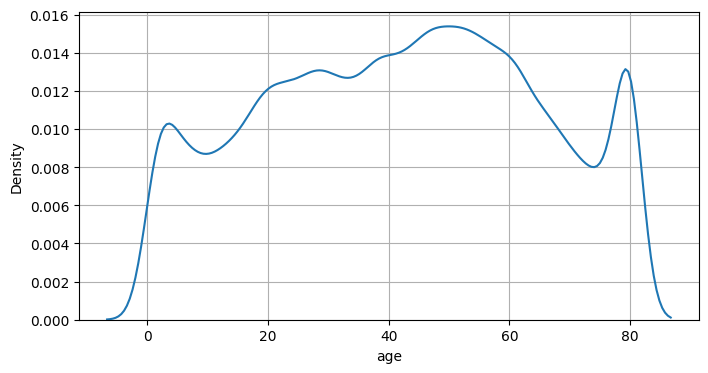

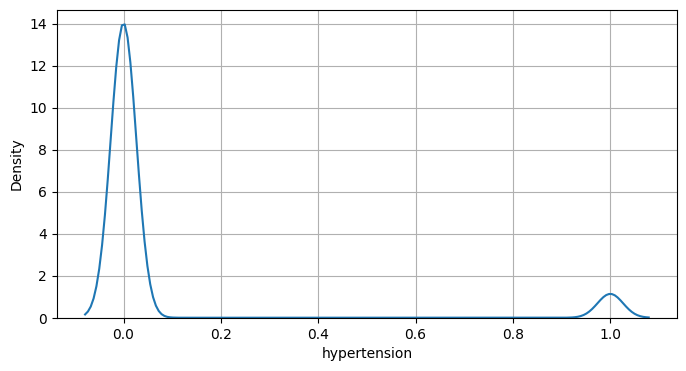

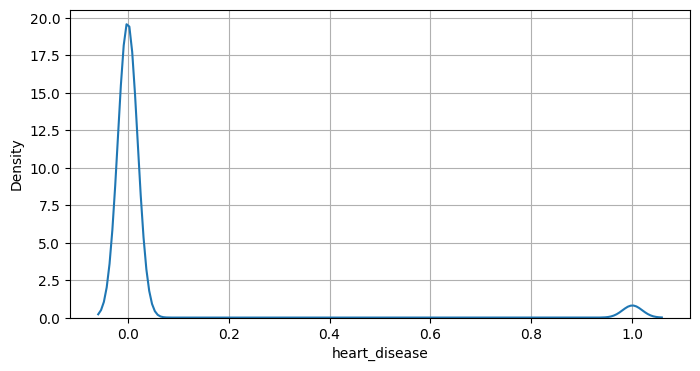

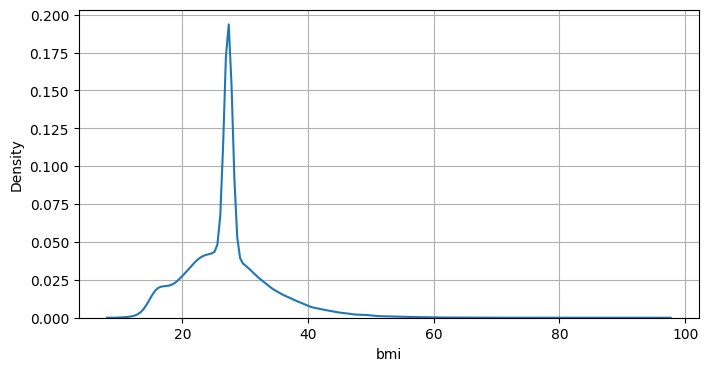

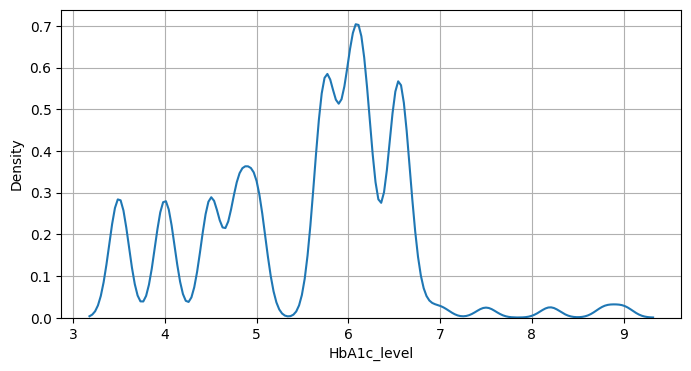

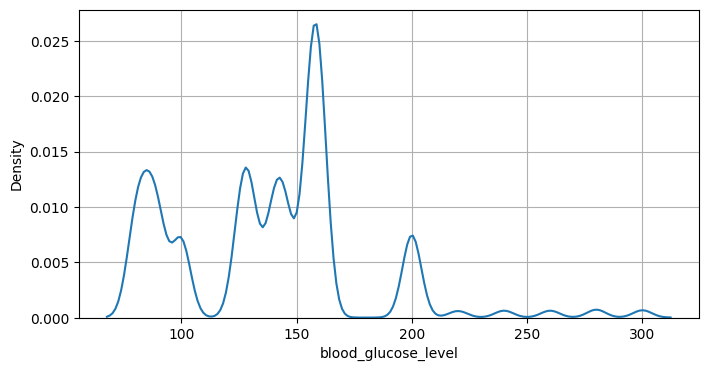

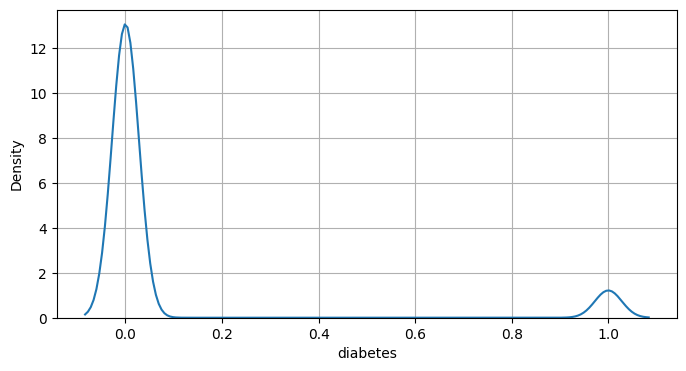

In [65]:
for i in num:
    sns.kdeplot(df[i])
    plt.grid()
    plt.show()

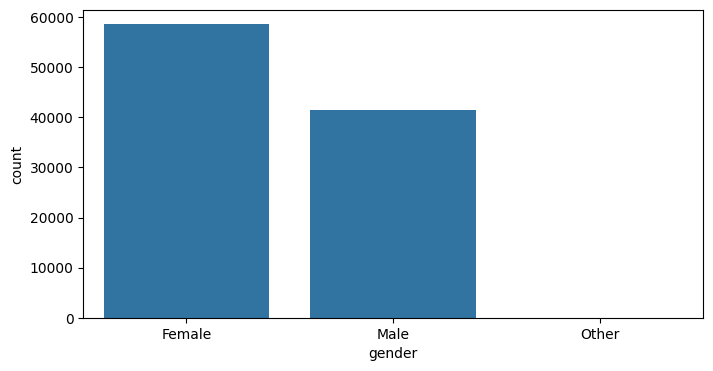

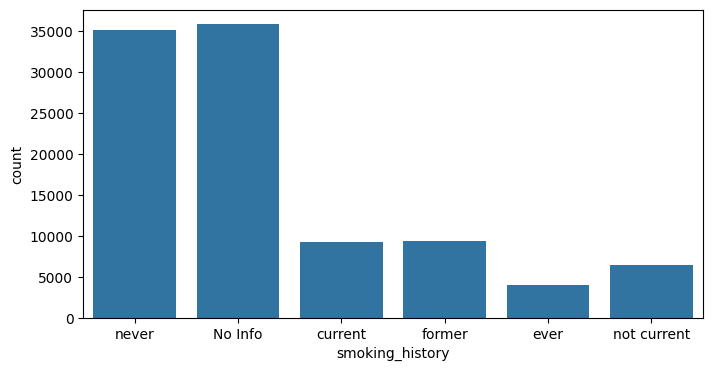

In [66]:
for i in cat:
    sns.countplot(x=df[i])
    plt.show()

In [67]:
bivariate = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level']

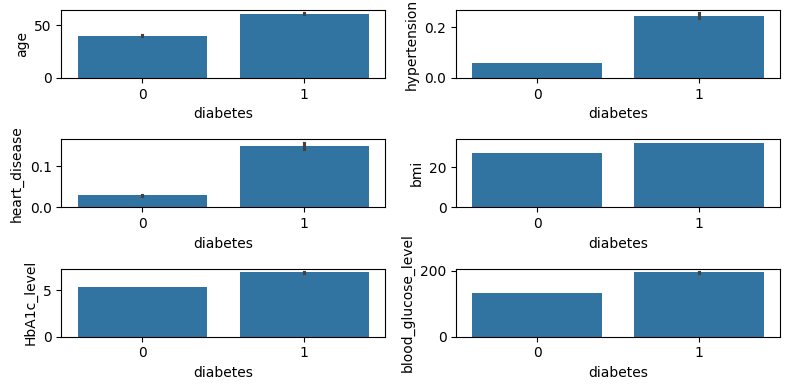

In [68]:
r=3
c=2
it=1
for i in bivariate:
    plt.subplot(r,c,it)
    sns.barplot(y=i,x='diabetes',data=df)
    it+=1
plt.tight_layout()
plt.show()

In [69]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [70]:
df = pd.get_dummies(df,columns=['gender','smoking_history'],drop_first=True)
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [71]:
y = df['diabetes']
x = df.drop('diabetes',axis=1)

In [72]:
from sklearn.preprocessing import StandardScaler

In [73]:
ss = StandardScaler()

In [74]:
x[['age','bmi','HbA1c_level','blood_glucose_level']] = ss.fit_transform(x[['age','bmi','HbA1c_level','blood_glucose_level']])
x.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,1.692704,0,1,-0.321056,1.001706,0.047704,False,False,False,False,False,True,False
1,0.538006,0,0,-0.000116,1.001706,-1.426210,False,False,False,False,False,False,False
2,-0.616691,0,0,-0.000116,0.161108,0.489878,True,False,False,False,False,True,False
3,-0.261399,0,0,-0.583232,-0.492690,0.416183,False,False,True,False,False,False,False
4,1.515058,1,1,-1.081970,-0.679490,0.416183,True,False,True,False,False,False,False


In [75]:
import statsmodels.api as sm

In [76]:
xc = sm.add_constant(x)


In [77]:
import statsmodels.api as sm
xc = sm.add_constant(xc)

In [78]:
xc.columns

Index(['const', 'age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'gender_Male', 'gender_Other',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='str')

In [79]:
x = x[['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'gender_Male', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current']]
x.head()
x.dtypes

age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level            float64
gender_Male                       bool
smoking_history_current           bool
smoking_history_ever              bool
smoking_history_former            bool
smoking_history_never             bool
smoking_history_not current       bool
dtype: object

In [80]:
from sklearn.model_selection import train_test_split

In [81]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.30,random_state=42)

In [82]:
from sklearn.linear_model import LogisticRegression

In [83]:
lr = LogisticRegression()

In [84]:
lr_model = lr.fit(xtrain,ytrain)
y_pred_train = lr_model.predict(xtrain)
y_pred_test = lr_model.predict(xtest)

In [85]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [86]:
print("The train accuracy score is: ",accuracy_score(ytrain,y_pred_train))
print("The test accuracy score is: ",accuracy_score(ytest,y_pred_test))

The train accuracy score is:  0.9609714285714286
The test accuracy score is:  0.9591333333333333


In [87]:
print("The train precision score is: ",precision_score(ytrain,y_pred_train))
print("The test precision score is: ",precision_score(ytest,y_pred_test))

The train precision score is:  0.8734059819151403
The test precision score is:  0.8623148656061437


In [88]:
print("The train recall score is: ",recall_score(ytrain,y_pred_train))
print("The test recall score is: ",recall_score(ytest,y_pred_test))

The train recall score is:  0.6327901898202587
The test recall score is:  0.6171967020023557


In [89]:
from sklearn.tree import DecisionTreeClassifier

In [90]:
dt = DecisionTreeClassifier()

In [91]:
dt_model = dt.fit(xtrain,ytrain)
y_pred_train = dt_model.predict(xtrain)
y_pred_test = dt_model.predict(xtest)

In [92]:
print("The train accuracy score is: ",accuracy_score(ytrain,y_pred_train))
print("The test accuracy score is: ",accuracy_score(ytest,y_pred_test))

The train accuracy score is:  0.9993142857142857
The test accuracy score is:  0.9518


In [93]:
print("The train precision score is: ",precision_score(ytrain,y_pred_train))
print("The test precision score is: ",precision_score(ytest,y_pred_test))

The train precision score is:  1.0
The test precision score is:  0.7089184060721062


In [94]:
print("The train recall score is: ",recall_score(ytrain,y_pred_train))
print("The test recall score is: ",recall_score(ytest,y_pred_test))

The train recall score is:  0.9919368385687889
The test recall score is:  0.7334118570867687


In [95]:
from sklearn.neighbors import KNeighborsClassifier

In [96]:
knn = KNeighborsClassifier()

In [97]:
knn_model = knn.fit(xtrain,ytrain)
y_pred_train = knn_model.predict(xtrain)
y_pred_test = knn_model.predict(xtest)

In [98]:
print("The train accuracy score is: ",accuracy_score(ytrain,y_pred_train))
print("The test accuracy score is: ",accuracy_score(ytest,y_pred_test))

The train accuracy score is:  0.9690857142857143
The test accuracy score is:  0.9601666666666666


In [99]:
print("The train precision score is: ",precision_score(ytrain,y_pred_train))
print("The test precision score is: ",precision_score(ytest,y_pred_test))

The train precision score is:  0.9503208937485144
The test precision score is:  0.8976470588235295


In [100]:
print("The train recall score is: ",recall_score(ytrain,y_pred_train))
print("The test recall score is: ",recall_score(ytest,y_pred_test))

The train recall score is:  0.6715941542079624
The test recall score is:  0.5991362387122104


In [110]:
from sklearn.preprocessing import StandardScaler
import joblib


def preprocess_data(df):
    X = df.drop("diabetes", axis=1)
    y = df["diabetes"]

    # SAVE FEATURE ORDER (CRITICAL)
    joblib.dump(X.columns.tolist(), "features.pkl")

    return X, y

from sklearn.preprocessing import StandardScaler
import joblib

X, y = preprocess_data(df)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, "scaler.pkl")



['scaler.pkl']

In [112]:
dt_model.fit(X_scaled, y)

joblib.dump(dt_model, "model.pkl")

['model.pkl']

['features.pkl']

In [113]:
FEATURES = joblib.load("features.pkl")

print("FEATURES COUNT:", len(FEATURES))
print("FEATURES LIST:", FEATURES)

FEATURES COUNT: 13
FEATURES LIST: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'gender_Male', 'gender_Other', 'smoking_history_current', 'smoking_history_ever', 'smoking_history_former', 'smoking_history_never', 'smoking_history_not current']


In [114]:
import joblib

model = joblib.load("model.pkl")
scaler = joblib.load("scaler.pkl")

print("Model expects:", model.n_features_in_)
print("Scaler expects:", scaler.n_features_in_)


Model expects: 13
Scaler expects: 13
